In [1]:
import pandas as pd

df = pd.DataFrame({
    "temp": [23, 21, 25, 18, 13, 16, 13, 17, 12],
    "takings": [3213, 2089, 2253, 1801, 801, 1934, 1720, 1514, 1017]
})

x, y = df["temp"], df["takings"]
x_mean, y_mean = x.mean(), y.mean()

b1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
b0 = y_mean - b1 * x_mean

print(b0, b1)   # about -353.1  123.5

-353.1148387096773 123.54451612903225


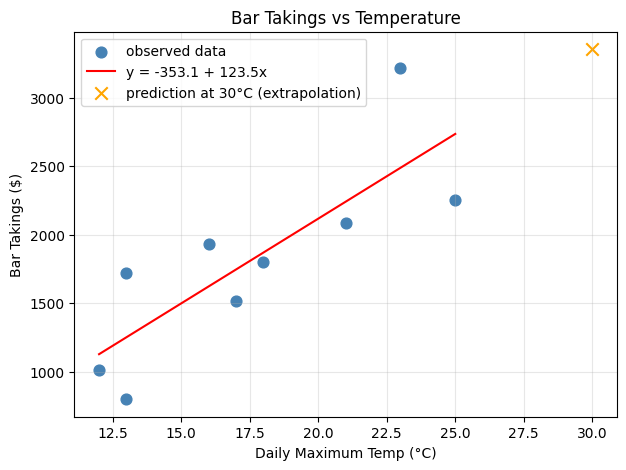

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame({
    "temp": [23, 21, 25, 18, 13, 16, 13, 17, 12],
    "takings": [3213, 2089, 2253, 1801, 801, 1934, 1720, 1514, 1017]
})

x, y = df["temp"], df["takings"]
x_mean, y_mean = x.mean(), y.mean()

b1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
b0 = y_mean - b1 * x_mean

# the fitted line, drawn from the lowest to highest x in the data
x_line = np.linspace(x.min(), x.max(), 50)
y_line = b0 + b1 * x_line

plt.figure(figsize=(7, 5))
plt.scatter(x, y, color="steelblue", s=60, label="observed data")
plt.plot(x_line, y_line, color="red", label=f"y = {b0:.1f} + {b1:.1f}x")

# the 30°C prediction, as an extrapolation
x_new = 30
y_new = b0 + b1 * x_new
plt.scatter(x_new, y_new, color="orange", s=80, marker="x", label="prediction at 30°C (extrapolation)")

plt.xlabel("Daily Maximum Temp (°C)")
plt.ylabel("Bar Takings ($)")
plt.title("Bar Takings vs Temperature")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "temp": [23, 21, 25, 18, 13, 16, 13, 17, 12],
    "takings": [3213, 2089, 2253, 1801, 801, 1934, 1720, 1514, 1017]
})

x, y = df["temp"], df["takings"]
x_mean, y_mean = x.mean(), y.mean()

# the regression line
b1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
b0 = y_mean - b1 * x_mean

df["y_on_line"] = b0 + b1 * x           # the line's value at that x (ŷ)

# the distance from the point to the line, straight up or down
df["distance"] = df["takings"] - df["y_on_line"]

print(df[["temp", "takings", "y_on_line", "distance"]])

   temp  takings    y_on_line    distance
0    23     3213  2488.409032  724.590968
1    21     2089  2241.320000 -152.320000
2    25     2253  2735.498065 -482.498065
3    18     1801  1870.686452  -69.686452
4    13      801  1252.963871 -451.963871
5    16     1934  1623.597419  310.402581
6    13     1720  1252.963871  467.036129
7    17     1514  1747.141935 -233.141935
8    12     1017  1129.419355 -112.419355


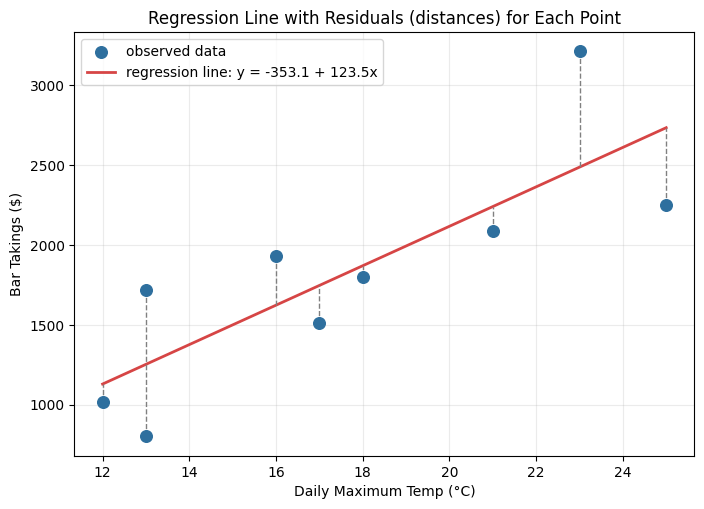

   temp  takings    y_on_line    distance
0    23     3213  2488.409032  724.590968
1    21     2089  2241.320000 -152.320000
2    25     2253  2735.498065 -482.498065
3    18     1801  1870.686452  -69.686452
4    13      801  1252.963871 -451.963871
5    16     1934  1623.597419  310.402581
6    13     1720  1252.963871  467.036129
7    17     1514  1747.141935 -233.141935
8    12     1017  1129.419355 -112.419355


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "temp": [23, 21, 25, 18, 13, 16, 13, 17, 12],
    "takings": [3213, 2089, 2253, 1801, 801, 1934, 1720, 1514, 1017]
})

x, y = df["temp"], df["takings"]
x_mean, y_mean = x.mean(), y.mean()

# the regression line
b1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
b0 = y_mean - b1 * x_mean

df["y_on_line"] = b0 + b1 * x                    # ŷ, the line's value at each x
df["distance"] = df["takings"] - df["y_on_line"]  # the residual

plt.figure(figsize=(8, 5.5))
plt.scatter(x, y, color="#2E6F9E", s=70, zorder=3, label="observed data")
plt.plot(x.sort_values(), b0 + b1 * x.sort_values(), color="#D64545",
         linewidth=2, label=f"regression line: y = {b0:.1f} + {b1:.1f}x")

# draw the distance from each point down (or up) to the line
for xi, yi, y_hat_i in zip(x, y, df["y_on_line"]):
    plt.plot([xi, xi], [yi, y_hat_i], color="gray", linestyle="--", linewidth=1, zorder=2)

plt.xlabel("Daily Maximum Temp (°C)")
plt.ylabel("Bar Takings ($)")
plt.title("Regression Line with Residuals (distances) for Each Point")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(df[["temp", "takings", "y_on_line", "distance"]])

In [5]:
print("sum of distances:", df["distance"].sum())

sum of distances: 9.094947017729282e-13


In [6]:
df["distance_sq"] = df["distance"] ** 2
sse = df["distance_sq"].sum()      # sum of squared residuals (SSE)

In [7]:
sst = ((df["takings"] - df["takings"].mean()) ** 2).sum()
r_squared_check = 1 - (sse / sst)
print(r_squared_check)   # should match r**2 from before

0.6571180598110715


In [8]:
sst = ((df["takings"] - df["takings"].mean()) ** 2).sum()
print("SST:", sst)

SST: 4000301.5555555555


In [9]:
r = df["temp"].corr(df["takings"])
r_squared = r ** 2

print("r  :", r)          # ≈ 0.86
print("R² :", r_squared)  # ≈ 0.74

r  : 0.8106281883891475
R² : 0.6571180598110712


intercept (β0): -353.1148387096773
slope (β1)    : 123.54451612903225

sum of residuals: 0.0
SSE: 1371631.1587096776
SST: 4000301.5555555555

r             : 0.8106281883891475
R² (from r)   : 0.6571180598110712
R² (from SSE) : 0.6571180598110715

p-value : 0.008041792377498271
std err : 33.73067691031866


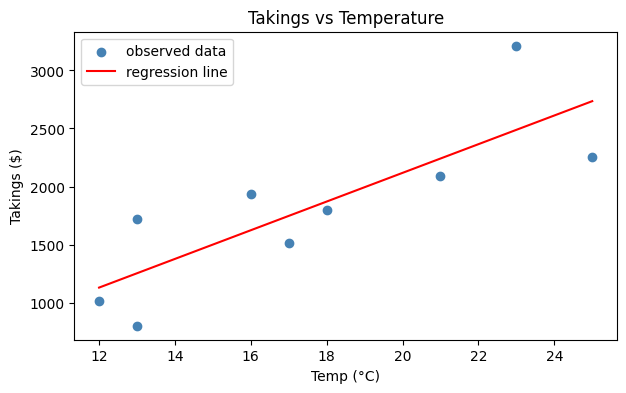

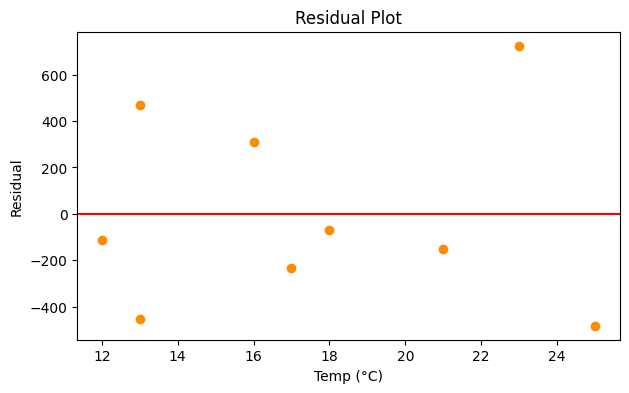

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Data
df = pd.DataFrame({
    "temp": [23, 21, 25, 18, 13, 16, 13, 17, 12],
    "takings": [3213, 2089, 2253, 1801, 801, 1934, 1720, 1514, 1017]
})

x, y = df["temp"], df["takings"]

# 2. Fit the line (β0, β1)
x_mean, y_mean = x.mean(), y.mean()
b1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
b0 = y_mean - b1 * x_mean
print("intercept (β0):", b0)
print("slope (β1)    :", b1)

# 3. Predictions and residuals
df["y_hat"] = b0 + b1 * x
df["distance"] = df["takings"] - df["y_hat"]

print("\nsum of residuals:", round(df["distance"].sum(), 6))   # should be 0

# 4. SSE and SST
sse = (df["distance"] ** 2).sum()
sst = ((df["takings"] - y_mean) ** 2).sum()
print("SSE:", sse)
print("SST:", sst)

# 5. r and R² (two ways, should match)
r = x.corr(y)
r_squared_from_r = r ** 2
r_squared_from_sse = 1 - (sse / sst)
print("\nr             :", r)
print("R² (from r)   :", r_squared_from_r)
print("R² (from SSE) :", r_squared_from_sse)

# 6. Significance check
res = stats.linregress(x, y)
print("\np-value :", res.pvalue)
print("std err :", res.stderr)

# 7. Scatter plot with the regression line
plt.figure(figsize=(7, 4))
plt.scatter(x, y, color="steelblue", label="observed data")
plt.plot(x.sort_values(), b0 + b1 * x.sort_values(), color="red", label="regression line")
plt.xlabel("Temp (°C)")
plt.ylabel("Takings ($)")
plt.title("Takings vs Temperature")
plt.legend()
plt.show()

# 8. Residual plot (check for patterns)
plt.figure(figsize=(7, 4))
plt.scatter(x, df["distance"], color="darkorange")
plt.axhline(0, color="red")
plt.xlabel("Temp (°C)")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## Interpreting r and R²

**r ≈ 0.81** — strength and direction of the relationship
- Positive sign: as temperature increases, takings tend to increase.
- Close to 1 (not 0): the points follow this upward trend fairly closely, a strong linear relationship.

**R² ≈ 0.66** — proportion of variation explained
- About **66%** of the day-to-day variation in takings is explained by temperature.
- The remaining **34%** is due to other factors not included in this model (e.g. day of week, local events, rain).

**Takeaway:** Temperature is a strong and useful predictor of bar takings, but not the whole story. A model based on temperature alone would still miss over a third of the variation, so other explanatory variables would likely improve the model further.